
# Principal Component Regression (PCR) Demonstration In Python

## Background
In multiple linear regression, the presence of strong linear relationships among independent variables leads to **multicollinearity**. 
While multicollinearity does not violate regression assumptions, it causes unstable coefficient estimates, inflated standard errors, 
and poor out-of-sample prediction performance.

One of the most widely used remedies for multicollinearity is **Principal Component Regression (PCR)**, which combines
Principal Component Analysis (PCA) with linear regression.



## Objectives
The objectives of this notebook are:
1. Detect multicollinearity using Variance Inflation Factor (VIF)
2. Understand PCA and variance explained
3. Build a Principal Component Regression model using `scikit-learn`
4. Compare PCR with Multiple Linear Regression on test data

## Data Description


| Variable | Description |
|---------|-------------|
| SRNO | Serial number  |
| SALES | Sales value for the corresponding period |
| AD | Advertising expenditure in the current period |
| PRO | Promotional activity level in the current period |
| SALEXP | Expected or planned sales indicator |
| ADPRE | Advertising expenditure in the previous period |
| PROPRE | Promotional activity level in the previous period |



### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices


### Load Training Data
Test data is assumed to be kept aside separately.


In [2]:
train_df = pd.read_csv("pcrdata.csv")
train_df.drop(columns = ['SRNO'],axis = 1,inplace = True)
train_df.head()

,SALES,AD,PRO,SALEXP,ADPRE,PROPRE
0,20.11,1.98,0.9,0.31,2.02,0.0
1,15.10,1.94,0.0,0.30,1.99,1.0
2,18.68,2.20,0.8,0.35,1.93,0.0
3,16.05,2.00,0.0,0.35,2.20,0.8
4,21.30,1.69,1.3,0.30,2.00,0.0



### Define Target and Predictors


In [3]:
X_train = train_df.drop(columns="SALES")
y_train = train_df["SALES"]


### Baseline Model: Multiple Linear Regression


In [4]:
lm = LinearRegression()
lm.fit(X_train, y_train)

y_train_pred_lm = lm.predict(X_train)

rmse_lm_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lm))
r2_lm_train = r2_score(y_train, y_train_pred_lm)

rmse_lm_train,r2_lm_train

(1.1758872769057398, 0.9088633180286636)


### Detecting Multicollinearity using VIF


In [5]:
# Design matrices using regression formula
y, X = dmatrices(
    'SALES ~ AD + PRO + SALEXP + ADPRE + PROPRE',
    data=train_df,
    return_type="dataframe"
)

# VIF calculation
vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=X.columns
)
vif

Intercept    4226.760949
AD             36.159771
PRO            31.846727
SALEXP          1.076284
ADPRE          24.781948
PROPRE         42.346468
dtype: float64

### Inference 
Several predictors (AD,PRO,ADPRE, SALEXP) show very high VIF values (>5), indicating severe multicollinearity.
Since removing a few variables may not sufficiently resolve this, we proceed with **Principal Component Regression (PCR)** to handle multicollinearity effectively.



### Principal Component Analysis (PCA)

It is recommended to standardize variables for PCA

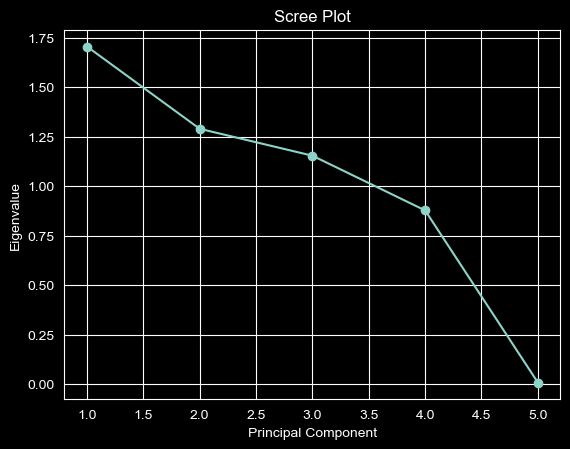

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

eigenvalues = pca.explained_variance_

plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()

Using the Kaiser criterion, components with eigenvalues greater than 1 are retained.
Since three PCs meet this rule, PC1, PC2, and PC3 are selected for analysis


### Principal Component Regression using sklearn Pipeline



First, all variables are **scaled** so they are on the same scale.
Then **PCA** compresses the original variables into **3 new uncorrelated components**, and finally a **linear regression model** is fitted using these components instead of the original variables.


### Note :

A scikit-learn pipeline automatically applies preprocessing steps only to X, while y is passed directly to the final estimator i.e LinearRegression without transformation.

In [7]:
pcr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=3)),
    ("regressor", LinearRegression())
])

pcr_model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=3)),
                ('regressor', LinearRegression())])


### Training Performance of PCR


In [8]:

y_train_pred_pcr = pcr_model.predict(X_train)

rmse_pcr_train = np.sqrt(mean_squared_error(y_train, y_train_pred_pcr))
r2_pcr_train = r2_score(y_train, y_train_pred_pcr)

rmse_pcr_train, r2_pcr_train


(2.794280895165522, 0.48536187831128874)


### Load Test Data and Evaluate Models


In [9]:
test_df = pd.read_csv("pcrdata_test.csv")
test_df.drop(columns = ['SRNO'],axis = 1,inplace = True)

X_test = test_df.drop(columns="SALES")
y_test = test_df["SALES"]

### Linear Regression on test data


In [10]:
y_test_pred_lm = lm.predict(X_test)
rmse_lm_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lm))

rmse_lm_test

9.111682179878756

### PCR on test data


In [11]:
y_test_pred_pcr = pcr_model.predict(X_test)
rmse_pcr_test = np.sqrt(mean_squared_error(y_test, y_test_pred_pcr))

rmse_pcr_test

2.851244990374772


### Model Comparison


In [12]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "PCR"],
    "RMSE (Test)": [rmse_lm_test, rmse_pcr_test],
})

comparison_df

,Model,RMSE (Test)
0,Linear Regression,9.111682
1,PCR,2.851245



### Conclusion
Principal Component Regression effectively addresses multicollinearity by regressing the response variable on a reduced set of 
orthogonal principal components, leading to improved prediction performance when predictors are highly correlated.
